# Bivariate luminosity estimation: public-count quick start

This notebook refits one predeclared mock catalogue using **only its public counts, recording geometry and initial mass**. The true Gaussian distribution and the discarded objects are not passed to the fitter. Run from the repository root after `python -m pip install -e .`.

The quick API uses recording-edge-aligned limits. It is an unconstrained simplex D-completion EM; the optional half-tail constraint is diagnosed, not imposed. A small score is not a global-optimality certificate. The complete earlier validation implementations are preserved separately in `reference_experiments/`.

In [1]:
from pathlib import Path
import json
import numpy as np
from bivsurv import GridModel, fit_em

ROOT = Path.cwd()
if not (ROOT / "outputs/visual/models/deep.json").exists():
    raise RuntimeError("Run this notebook from the repository root.")
output = ROOT / "outputs/visual"
case = "rho0.55_N16000_r000"
model = GridModel.from_dict(json.loads((output / "models/deep.json").read_text()))
public = json.loads((output / "public_counts/deep" / (case + ".json")).read_text())
with np.load(output / "models/deep_arrays.npz") as archive:
    initial = archive["initial"].copy()
counts = [np.asarray(row) for row in public["counts"]]
print("Observed records:", sum(int(row.sum()) for row in counts))
print("Full-plane mass cells:", model.H)

Observed records: 12884
Full-plane mass cells: 1156


In [2]:
fit = fit_em(model, counts, initial, score_tolerance=1e-7,
             max_iterations=20000, tail_upper=0.5)
print("Status:", fit.status)
print("Iterations:", fit.iterations)
print("Maximum mean score:", fit.score)
print("Tail-class diagnostic:", fit.tail_feasible)
print("Invisible mass drift:", fit.invisible_mass_drift)

# Read saved fitted mass only for a reproducibility comparison, after fitting.
with np.load(output / "fits/deep" / (case + ".npz")) as archive:
    saved_mass = archive["mass"].copy()
np.testing.assert_allclose(fit.mass, saved_mass, atol=1e-12, rtol=1e-10)
print("Saved fit reproduced.")

Status: score_tolerance_reached_not_global_certificate
Iterations: 43
Maximum mean score: 7.197319415550247e-08
Tail-class diagnostic: True
Invisible mass drift: 0.0
Saved fit reproduced.


## The resolved bivariate luminosity shape

The displayed density is a bin-average of `Q_U = P(. | U)`, where `U` is the union of the declared detection regions. The Gaussian truth is conditioned on the same set. Hatched unresolved regions are **not filled by a density extrapolation**. The invisible normalization of the full parent is not identified by this picture.

The following is a saved numerical figure, generated by `python scripts/make_figures.py`, not an artistic illustration.

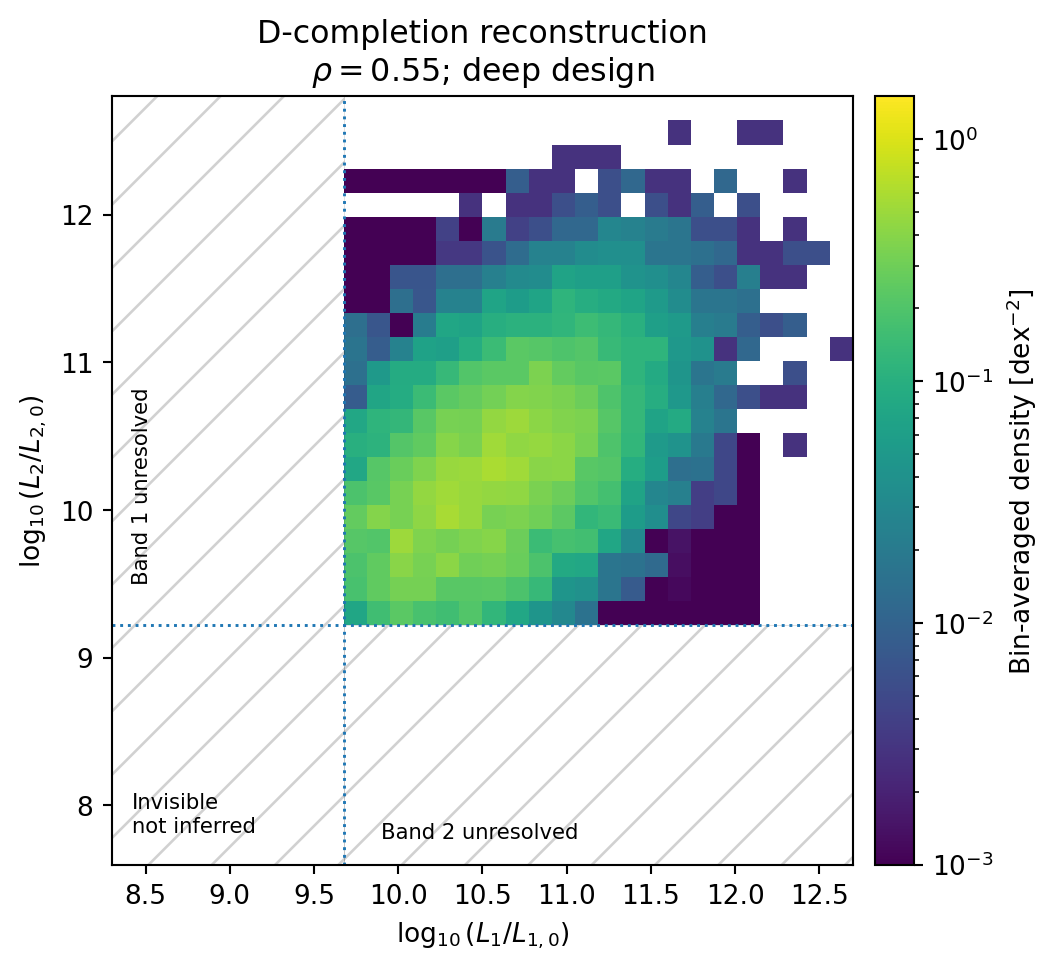

In [3]:
from IPython.display import Image, display
figure = output / "figures/rho0.55_deep_reconstructed_Q.png"
if not figure.exists():
    raise RuntimeError("Generate the figures with python scripts/make_figures.py first.")
display(Image(filename=str(figure), width=650))

## Reproduce the full experiment

Use a separate output directory so the distributed numerical evidence is not overwritten:

```bash
python -m pytest -q
python scripts/run_benchmark.py --output outputs/rerun
python scripts/verify_visual.py --output outputs/rerun
python scripts/make_figures.py --output outputs/rerun
python scripts/check_initialization.py --output outputs/rerun
```

Compare the fresh result with the preserved result, writing the new report only in the fresh output directory:

```bash
python scripts/verify_visual.py --output outputs/rerun --compare-rerun outputs/visual
```

The 20-replicate plot bands are empirical 10th–90th percentiles, not 95% confidence intervals. The same-likelihood family figures are not confidence bands either. The new high-resolution fits have numerical diagnostics; rigorous Stage 25 certificates concern a different, preserved 13-case experiment.

Continue with the [English documentation index](docs/README.md), [results](docs/RESULTS.md), [reference experiments](docs/reference/README.md), or [release checklist](docs/RELEASE_CHECKLIST.md). Original Japanese notes and manuscript fragments are optional historical sources, not required reading for these instructions.
